# agentv4_conditional_edges — Conditional Routing

This version introduces explicit conditional edges.

Graph shape:

```text
START → classifier → [math_agent | time_agent | general_agent] → END
```

`agentv3_tool_calling` used `tools_condition`, a prebuilt conditional router for tool calls.

`agentv4_conditional_edges` shows how to build your own routing logic.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables

The general route uses a real OpenAI model.

```env
OPENAI_API_KEY=your_openai_api_key
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=your_langsmith_api_key
LANGSMITH_PROJECT=langgraph-playground
```


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("Current directory:", cwd)
print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


Current directory: /home/aimlnode/Workplace/Projects/langgraph-playground/langgraph-playground-v1-notebook/agentv4_conditional_edges
OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define graph state

This version adds a new field:

- `route`: routing decision made by the classifier

The route determines which node runs next.


In [3]:
from typing import Literal, TypedDict

RouteName = Literal["math", "time", "general"]

class AgentState(TypedDict, total=False):
    input: str
    route: RouteName
    answer: str


## 4. Define a small safe calculator

The math route uses a local deterministic calculator.

This is not mocked. It evaluates real arithmetic, but only allows a restricted expression syntax.


In [4]:
import ast
import operator
import re

_ALLOWED_BINOPS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.FloorDiv: operator.floordiv,
    ast.Mod: operator.mod,
    ast.Pow: operator.pow,
}

_ALLOWED_UNARYOPS = {
    ast.UAdd: operator.pos,
    ast.USub: operator.neg,
}

def _eval_math_expr(node: ast.AST) -> float:
    if isinstance(node, ast.Expression):
        return _eval_math_expr(node.body)

    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value

    if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_BINOPS:
        left = _eval_math_expr(node.left)
        right = _eval_math_expr(node.right)
        return _ALLOWED_BINOPS[type(node.op)](left, right)

    if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_UNARYOPS:
        operand = _eval_math_expr(node.operand)
        return _ALLOWED_UNARYOPS[type(node.op)](operand)

    raise ValueError("Unsupported expression.")

def safe_calculate(expression: str) -> str:
    tree = ast.parse(expression, mode="eval")
    return str(_eval_math_expr(tree))

def extract_arithmetic_expression(text: str) -> str:
    match = re.search(r"[0-9\.\s\+\-\*\/\(\)%]+", text)
    if not match:
        raise ValueError("No arithmetic expression found.")
    return match.group(0).strip()


## 5. Define classifier node

The classifier chooses one of three routes:

- `math`
- `time`
- `general`

For v4, the classifier is deterministic. In later versions, the router can be LLM-based.


In [5]:
def classifier_node(state: AgentState) -> AgentState:
    text = state.get("input", "").lower()

    math_terms = ["calculate", "math", "multiply", "plus", "minus", "divide", "*", "+", "-", "/", "**"]
    time_terms = ["time", "utc", "date", "now", "today"]

    if any(term in text for term in math_terms) and re.search(r"\d", text):
        return {"route": "math"}

    if any(term in text for term in time_terms):
        return {"route": "time"}

    return {"route": "general"}


## 6. Define branch nodes

Each branch is a separate node.

This keeps workflows clean and modular.


In [6]:
from datetime import datetime, timezone
from langchain_openai import ChatOpenAI

def math_agent_node(state: AgentState) -> AgentState:
    try:
        expr = extract_arithmetic_expression(state["input"])
        result = safe_calculate(expr)
        return {"answer": f"Math route selected. {expr} = {result}"}
    except Exception as exc:
        return {"answer": f"Math route selected, but calculation failed: {exc}"}

def time_agent_node(state: AgentState) -> AgentState:
    now = datetime.now(timezone.utc).isoformat()
    return {"answer": f"Time route selected. Current UTC time is {now}"}

def general_agent_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    response = llm.invoke(state.get("input", "Explain LangGraph briefly."))
    return {"answer": f"General route selected. {response.content}"}


## 7. Define route selector

`add_conditional_edges` needs a routing function.

It receives current state and returns the route key.


In [7]:
def route_selector(state: AgentState) -> RouteName:
    return state["route"]


## 8. Build graph with conditional edges

The key call is:

```python
graph_builder.add_conditional_edges(...)
```

That maps route values to destination nodes.


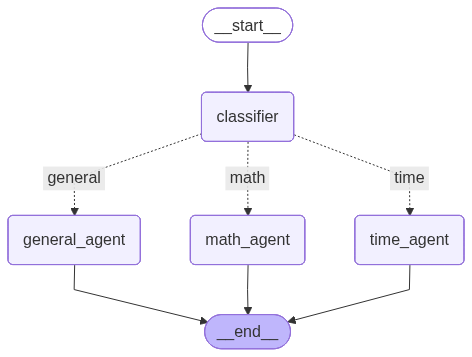

In [8]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("classifier", classifier_node)
    graph_builder.add_node("math_agent", math_agent_node)
    graph_builder.add_node("time_agent", time_agent_node)
    graph_builder.add_node("general_agent", general_agent_node)

    graph_builder.add_edge(START, "classifier")

    graph_builder.add_conditional_edges(
        "classifier",
        route_selector,
        {
            "math": "math_agent",
            "time": "time_agent",
            "general": "general_agent",
        },
    )

    graph_builder.add_edge("math_agent", END)
    graph_builder.add_edge("time_agent", END)
    graph_builder.add_edge("general_agent", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 9. Visualize Mermaid graph


In [9]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classifier(classifier)
	math_agent(math_agent)
	time_agent(time_agent)
	general_agent(general_agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> classifier;
	classifier -. &nbsp;general&nbsp; .-> general_agent;
	classifier -. &nbsp;math&nbsp; .-> math_agent;
	classifier -. &nbsp;time&nbsp; .-> time_agent;
	general_agent --> __end__;
	math_agent --> __end__;
	time_agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize PNG graph


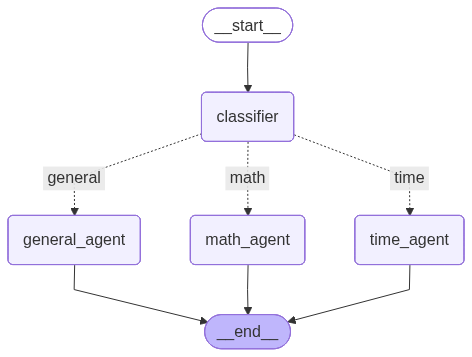

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 11. Test math route


In [11]:
result = graph.invoke({"input": "What is 25 * 12?"})
result


{'input': 'What is 25 * 12?',
 'route': 'math',
 'answer': 'Math route selected, but calculation failed: invalid syntax (<unknown>, line 0)'}

## 12. Test time route


In [12]:
result = graph.invoke({"input": "What is the current UTC time?"})
result


{'input': 'What is the current UTC time?',
 'route': 'time',
 'answer': 'Time route selected. Current UTC time is 2026-06-25T19:35:14.963922+00:00'}

## 13. Test general route


In [13]:
result = graph.invoke({"input": "Explain LangGraph in two short sentences."})
result


{'input': 'Explain LangGraph in two short sentences.',
 'route': 'general',
 'answer': 'General route selected. LangGraph is a framework designed for building and managing language models by leveraging graph-based structures to enhance their understanding and generation capabilities. It integrates various linguistic and contextual information, allowing for more nuanced and context-aware language processing.'}

## 14. Batch test routing

This helps verify route behavior quickly.


In [14]:
test_inputs = [
    "What is 10 + 15?",
    "What is the current UTC time?",
    "Explain what a graph node means.",
]

for text in test_inputs:
    result = graph.invoke({"input": text})
    print("\nINPUT:", text)
    print("ROUTE:", result["route"])
    print("ANSWER:", result["answer"])



INPUT: What is 10 + 15?
ROUTE: math
ANSWER: Math route selected, but calculation failed: invalid syntax (<unknown>, line 0)

INPUT: What is the current UTC time?
ROUTE: time
ANSWER: Time route selected. Current UTC time is 2026-06-25T19:35:38.117432+00:00

INPUT: Explain what a graph node means.
ROUTE: general
ANSWER: General route selected. A graph node, also known as a vertex, is a fundamental unit of a graph in graph theory. A graph is a collection of nodes (or vertices) connected by edges (or links). Each node represents an entity or a point in the graph, while the edges represent the relationships or connections between these entities.

In more detail:

1. **Node (Vertex)**: This is a discrete point in the graph. It can represent various entities depending on the context, such as:
   - In a social network graph, a node might represent a person.
   - In a transportation network, a node could represent a city or a station.
   - In a computer network, a node might represent a device

## 15. Reusable run function


In [ ]:
def run(text: str = "Explain LangGraph briefly.") -> AgentState:
    return graph.invoke({"input": text})

run("Calculate 144 / 12")


## 16. Check LangSmith traces

Open LangSmith project:

```text
langgraph-playground
```

Expected trace shape:

```text
Graph run
  ├── classifier
  └── selected branch
        ├── math_agent
        ├── time_agent
        └── general_agent
```

For `general_agent`, you should also see a real OpenAI chat model call.

For `math_agent` and `time_agent`, you should see deterministic local node execution.


## 17. What changed from v3 to v4

v3 used tool-call routing:

```text
assistant → tools_condition → tools or END
```

v4 uses custom workflow routing:

```text
classifier → route_selector → selected branch
```

This is the foundation for:

- router agents
- supervisor agents
- multi-agent orchestration
- intent-based workflows
- A2A dispatch patterns
